## MVP
MVP com Logistic Regressor

## Objetivo
Construir modelos baseline para previsão de churn e estabelecer uma referência mínima de desempenho antes da aplicação de modelos mais complexos.

## Modelos avaliados
- DummyClassifier
- LogisticRegression

## Métrica principal
A métrica principal adotada é **Recall**, pois, no contexto de churn, deixar de identificar um cliente com risco de cancelamento tende a ser mais crítico do que classificar incorretamente um cliente como churn.

## Métricas secundárias
- Precision
- F1 Score
- ROC-AUC
- PR-AUC
- Accuracy


## Imports


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    roc_auc_score,
    recall_score
)

import seaborn as sns
# TODO - verificar uso

# TODO - verificar uso - joblib.dump(model, MODELS_DIR / "baseline_model.pkl")
from utils.config import get_models_dir
import joblib

MODELS_DIR = get_models_dir()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# experiment tracking
import mlflow
import mlflow.sklearn

# projeto
# TODO - REMOVER se possível e substituir por
# from src.data.data_loader import DataLoader
# from src.utils.config import get_dataset_path
import sys
from pathlib import Path
sys.path.append(str(Path('../../src').resolve()))


## Carregamento dos dados

In [18]:
# leitura dos dados
df_encoded = pd.read_csv('../../data/processed/processed_customer_churn.csv')

# rename Chrun to target
df_encoded.rename(columns={'Churn': 'target'}, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/processed/processed_customer_churn.csv'

In [ ]:
# show all collumns
pd.set_option('display.max_columns', None)
df_encoded.head()

,customerID,tenure,MonthlyCharges,TotalCharges,target,FamilyStatus,TenureBin,FamilySizeProxy,RiskProfile,RiskCombo,SupportBundle,DiffMonthlyCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,No,Family,0-12,2,Low Risk,High Risk,No Bundle,0.000000,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,No,Single,25-48,1,Low Risk,Low Risk,No Bundle,1.376471,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,Yes,Single,0-12,1,Low Risk,Low Risk,No Bundle,-0.225000,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,No,Single,25-48,1,Low Risk,Low Risk,Has Bundle,1.394444,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,Yes,Single,0-12,1,Low Risk,High Risk,No Bundle,-5.125000,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## Preparação mínima dos dados e definição do target


In [ ]:
# convert target to binary
df_encoded['target'] = df_encoded['target'].map({'Yes': 1, 'No': 0}).astype(int)

# variaveis categoricas para análise
categorial_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", 
                   "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", 
                   "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
                   "RiskCombo", "SupportBundle", "FamilySizeProxy","FamilyStatus","RiskProfile"]



In [ ]:
# remove colunas não numéricas que não devem entrar no modelo
X = df_encoded.drop(columns=["Churn", 'customerID', 'target'], errors='ignore')
y = df_encoded['target']

In [ ]:
# convert total charges to numeric, coercing errors to NaN, round2 decimals
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce').round(2)
X['MonthlyCharges'] = pd.to_numeric(X['MonthlyCharges'], errors='coerce').round(2)
X['DiffMonthlyCharges'] = pd.to_numeric(X['DiffMonthlyCharges'], errors='coerce').round(2)

Colunas numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges', 'FamilySizeProxy', 'DiffMonthlyCharges']
Colunas categóricas: ['FamilyStatus', 'TenureBin', 'RiskProfile', 'RiskCombo', 'SupportBundle', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## Separação entre variáveis numéricas e categóricas

In [ ]:
# convert total charges to numeric, coercing errors to NaN, round2 decimals
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce').round(2)
X['MonthlyCharges'] = pd.to_numeric(X['MonthlyCharges'], errors='coerce').round(2)
X['DiffMonthlyCharges'] = pd.to_numeric(X['DiffMonthlyCharges'], errors='coerce').round(2)

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorial_features = X.select_dtypes(include=['object','bool']).columns.tolist()

print("Colunas numéricas:", numeric_features)
print("Colunas categóricas:", categorial_features)

NameError: name 'X' is not defined

In [ ]:
# max display columns
pd.set_option('display.max_columns', None)
df_encoded.head()

,customerID,tenure,MonthlyCharges,TotalCharges,target,FamilyStatus,TenureBin,FamilySizeProxy,RiskProfile,RiskCombo,SupportBundle,DiffMonthlyCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,Family,0-12,2,Low Risk,High Risk,No Bundle,0.000000,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,5575-GNVDE,34,56.95,1889.50,0,Single,25-48,1,Low Risk,Low Risk,No Bundle,1.376471,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,2,53.85,108.15,1,Single,0-12,1,Low Risk,Low Risk,No Bundle,-0.225000,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,7795-CFOCW,45,42.30,1840.75,0,Single,25-48,1,Low Risk,Low Risk,Has Bundle,1.394444,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,9237-HQITU,2,70.70,151.65,1,Single,0-12,1,Low Risk,High Risk,No Bundle,-5.125000,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## Pipeline de pré-processamento

In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorial_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

processor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorial_transformer, categorial_features)
])

## SPLIT Estratificado

In [ ]:
# split estratificado para manter a proporção de classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

## Definição dos modelos baseline

In [ ]:
models = {
    "dummy": DummyClassifier(strategy='most_frequent'),
    "LogisticRegression": LogisticRegression(max_iter=1000,
                                             random_state=42,
                                             penalty='l2',
                                             class_weight='balanced')
}

## Validação cruzada estratificada

In [ ]:
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate

pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_map = {}
cv_scores_raw = {}

for model_name, model in models.items():
    pipeline_cv = Pipeline(steps=[
        ('preprocessor', processor),
        ('model', model)
    ])

    scoring = {
        'accuracy':  'accuracy',
        'f1':        'f1',
        'precision': 'precision',
        'recall':    'recall',
        'roc_auc':   'roc_auc',
        'pr_auc':    pr_auc_scorer,
    }

    scores = cross_validate(
        pipeline_cv, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_scores_raw[model_name] = scores

    cv_results_map[model_name] = {
        "cv_accuracy":  scores['test_accuracy'].mean(),
        "cv_f1":        scores['test_f1'].mean(),
        "cv_precision": scores['test_precision'].mean(),
        "cv_recall":    scores['test_recall'].mean(),
        "cv_roc_auc":   scores['test_roc_auc'].mean(),
        "cv_pr_auc":    scores['test_pr_auc'].mean(),
    }

# resultado por fold no terminal
for model_name, scores in cv_scores_raw.items():
    print(f"\n── {model_name} ──")
    for metric, values in scores.items():
        if metric.startswith('test_'):
            label = metric.replace('test_', '')
            print(f"  {label:12s}: {values.mean():.4f} ± {values.std():.4f}")

c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted sampl


── dummy ──
  accuracy    : 0.7346 ± 0.0001
  f1          : 0.0000 ± 0.0000
  precision   : 0.0000 ± 0.0000
  recall      : 0.0000 ± 0.0000
  roc_auc     : 0.5000 ± 0.0000
  pr_auc      : 0.2654 ± 0.0001

── LogisticRegression ──
  accuracy    : 0.7481 ± 0.0146
  f1          : 0.6253 ± 0.0244
  precision   : 0.5164 ± 0.0181
  recall      : 0.7926 ± 0.0399
  roc_auc     : 0.8450 ± 0.0122
  pr_auc      : 0.6612 ± 0.0136

── DecisionTree ──
  accuracy    : 0.7235 ± 0.0228
  f1          : 0.5994 ± 0.0183
  precision   : 0.4890 ± 0.0282
  recall      : 0.7786 ± 0.0439
  roc_auc     : 0.8262 ± 0.0114
  pr_auc      : 0.5963 ± 0.0205


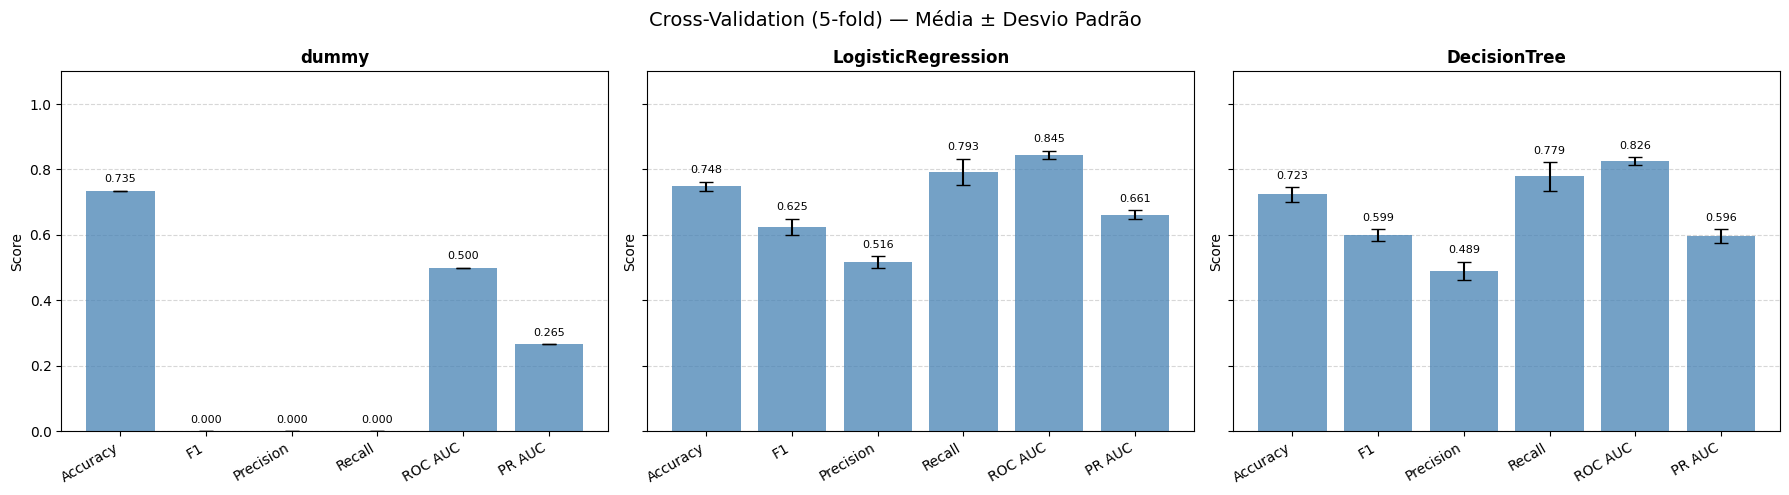

In [ ]:
metrics_labels = {
    'test_accuracy':  'Accuracy',
    'test_f1':        'F1',
    'test_precision': 'Precision',
    'test_recall':    'Recall',
    'test_roc_auc':   'ROC AUC',
    'test_pr_auc':    'PR AUC'
}

fig, axes = plt.subplots(1, len(cv_scores_raw), figsize=(18, 5), sharey=True)

for ax, (model_name, scores) in zip(axes, cv_scores_raw.items()):
    means = [scores[m].mean() for m in metrics_labels]
    stds  = [scores[m].std()  for m in metrics_labels]
    x     = np.arange(len(metrics_labels))

    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color='steelblue', alpha=0.75, ecolor='black')

    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels.values(), rotation=30, ha='right')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.02,
                f"{mean:.3f}", ha='center', va='bottom', fontsize=8)

fig.suptitle("Cross-Validation (5-fold) — Média ± Desvio Padrão", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

mlflow.set_experiment("tech-challenge-fase01-baseline")

holdout_results = []
fitted_pipelines = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):

        pipeline = Pipeline(steps=[
            ('preprocessor', processor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)
        fitted_pipelines[model_name] = pipeline

        y_pred = pipeline.predict(X_test)

        roc_auc = None
        pr_auc  = None
        if hasattr(pipeline.named_steps['model'], "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
            pr_auc  = average_precision_score(y_test, y_proba)

        metrics = {
            "accuracy":  accuracy_score(y_test, y_pred),
            "f1_score":  f1_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall":    recall_score(y_test, y_pred),
        }
        if roc_auc is not None:
            metrics["roc_auc"] = roc_auc
        if pr_auc is not None:
            metrics["pr_auc"] = pr_auc

        mlflow.log_params(model.get_params())
        mlflow.log_metrics(cv_results_map[model_name])
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipeline, artifact_path="model")

        model_file = MODELS_DIR / f"{model_name}.pkl"
        joblib.dump(pipeline, model_file)
        mlflow.log_artifact(str(model_file))

        holdout_results.append({"model": model_name, **metrics, "roc_auc": roc_auc, "pr_auc": pr_auc})

c:\Users\gfrei\Documents\1. FIAP\3. FASE1\9. TECH_CHALLENGE\tech-challenge-fase01\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/04/18 21:25:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 21:25:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/18 21:25:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be ad

In [ ]:
results_df = pd.DataFrame(holdout_results).set_index("model")
results_df

,accuracy,f1_score,precision,recall,roc_auc,pr_auc
model,,,,,,
dummy,0.734564,0.000000,0.000000,0.000000,0.500000,0.265436
LogisticRegression,0.740951,0.616999,0.507772,0.786096,0.842763,0.638261
DecisionTree,0.734564,0.617587,0.500000,0.807487,0.830024,0.596254


## Interpretação dos resultados

O DummyClassifier representa um baseline ingênuo e serve como referência mínima para comparação.

A Regressão Logística apresentou desempenho superior nas métricas mais relevantes, especialmente em Recall e F1 Score, indicando que o modelo consegue aprender padrões úteis relacionados ao churn.

Como o problema apresenta desbalanceamento de classes, Accuracy não foi tratada como métrica principal. Recall foi priorizado por refletir melhor a capacidade do modelo de identificar clientes com risco de cancelamento.

Esse baseline estabelece uma referência adequada para comparação futura com modelos mais complexos.